In [1]:
import os
import pandas as pd

In [4]:
# Kaggle dataset path
DATA_PATH = "/kaggle/input/datasets/daluanjali/vinbig-ass"

CSV_PATH = os.path.join(DATA_PATH, "Data/train.csv")
IMAGE_DIR = os.path.join(DATA_PATH, "images", "train")

# Load CSV
df = pd.read_csv(CSV_PATH)

print("Dataset Loaded Successfully\n")

# Basic info
print("CSV Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

# Unique images
unique_images = df["image_id"].nunique()
print("\nTotal Unique Images:", unique_images)

# Unique classes
unique_classes = df["class_id"].nunique()
print("Total Unique Classes:", unique_classes)

# Verify image folder
print("\nChecking image directory...")
print("Total images in folder:", len(os.listdir(IMAGE_DIR)))

# Check sample image path
sample_image = df.iloc[0]["image_id"]
sample_path = os.path.join(IMAGE_DIR, sample_image + ".jpg")

print("\nSample Image Path:", sample_path)
print("Image Exists:", os.path.exists(sample_path))

Dataset Loaded Successfully

CSV Shape: (67914, 8)

Columns:
Index(['image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min',
       'x_max', 'y_max'],
      dtype='object')

First 5 rows:


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN



Total Unique Images: 15000
Total Unique Classes: 15

Checking image directory...
Total images in folder: 15000

Sample Image Path: /kaggle/input/datasets/daluanjali/vinbig-ass/images/train/50a418190bc3fb1ef1633bf9678929b3.jpg
Image Exists: True


In [ ]:
# Extract unique class mapping
class_mapping = df[['class_id', 'class_name']].drop_duplicates().sort_values('class_id')

print("Total Classes:", len(class_mapping))
print("\nClass Mapping (ID -> Name):\n")

display(class_mapping)


# Convert mapping to dictionary
class_dict = dict(zip(class_mapping.class_id, class_mapping.class_name))

print("\nClass Dictionary:\n")
print(class_dict)

Total Classes: 15

Class Mapping (ID -> Name):



,class_id,class_name
3,0,Aortic enlargement
17,1,Atelectasis
109,2,Calcification
2,3,Cardiomegaly
116,4,Consolidation
6,5,ILD
37,6,Infiltration
10,7,Lung Opacity
7,8,Nodule/Mass
31,9,Other lesion



Class Dictionary:

{0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity', 8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening', 12: 'Pneumothorax', 13: 'Pulmonary fibrosis', 14: 'No finding'}


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


Classification Dataset Shape: (15000, 8)

Images per class:

Aortic enlargement : 1127
Atelectasis : 30
Calcification : 91
Cardiomegaly : 878
Consolidation : 46
ILD : 111
Infiltration : 134
Lung Opacity : 251
Nodule/Mass : 221
Other lesion : 224
Pleural effusion : 241
Pleural thickening : 496
Pneumothorax : 22
Pulmonary fibrosis : 522
No finding : 10606


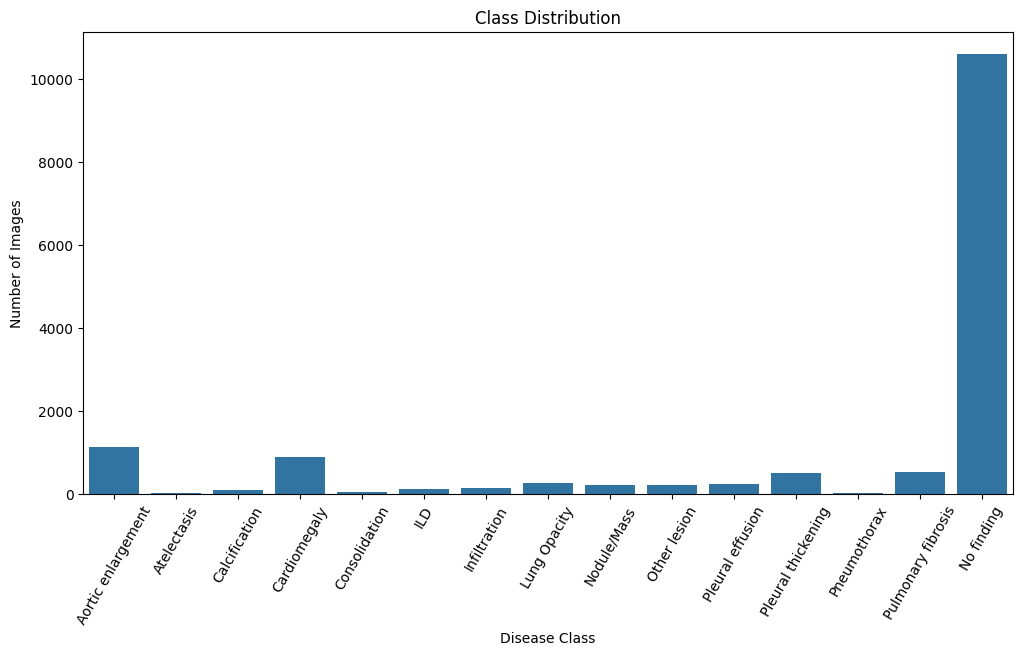

In [7]:
# Convert detection dataset -> classification dataset
df_cls = df.groupby("image_id").first().reset_index()

print("Classification Dataset Shape:", df_cls.shape)

# Count images per class
class_counts = df_cls["class_id"].value_counts().sort_index()

print("\nImages per class:\n")
for class_id, count in class_counts.items():
    print(f"{class_dict[class_id]} : {count}")

# Plot class distribution
plt.figure(figsize=(12,6))

sns.barplot(
    x=[class_dict[i] for i in class_counts.index],
    y=class_counts.values
)

plt.xticks(rotation=60)
plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.show()

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import timm
import os

In [9]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [10]:
train_df, val_df = train_test_split(
    df_cls,
    test_size=0.2,
    stratify=df_cls["class_id"],
    random_state=42
)

print("Train Images:", len(train_df))
print("Validation Images:", len(val_df))

Train Images: 12000
Validation Images: 3000


In [11]:
class VinBigDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_id = self.df.iloc[idx]["image_id"]
        label = int(self.df.iloc[idx]["class_id"])

        img_path = os.path.join(image_dir, image_id + ".jpg")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [12]:
train_tfms = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

val_tfms = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor()
])

In [ ]:
image_dir = IMAGE_DIR

train_dataset = VinBigDataset(train_df, image_dir, train_tfms)
val_dataset = VinBigDataset(val_df, image_dir, val_tfms)

In [14]:
class_counts = train_df["class_id"].value_counts().sort_index()

class_weights = 1.0 / class_counts
sample_weights = train_df["class_id"].map(class_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights.values,
    num_samples=len(sample_weights),
    replacement=True
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 750
Validation batches: 188


In [16]:
model = timm.create_model(
    "densenet121",
    pretrained=True,
    num_classes=15
)

model = model.to(device)

print("\nDenseNet121 Loaded Successfully")

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]


DenseNet121 Loaded Successfully


In [17]:
import torch.optim as optim
from tqdm import tqdm
import numpy as np

In [18]:
class_counts = train_df["class_id"].value_counts().sort_index()

weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float)
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 5

best_val_acc = 0

In [19]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # -------------------
    # Training
    # -------------------
    
    model.train()
    
    train_loss = 0
    train_correct = 0
    total_train = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = train_correct / total_train
    train_loss = train_loss / len(train_loader)


    # -------------------
    # Validation
    # -------------------

    model.eval()

    val_loss = 0
    val_correct = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in tqdm(val_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_acc = val_correct / total_val
    val_loss = val_loss / len(val_loader)


    print(f"\nTrain Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


    # -------------------
    # Save Best Model
    # -------------------

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), "best_densenet121_model.pth")

        print("Best model saved!")


Epoch 1/5


100%|██████████| 188/188 [00:51<00:00,  3.62it/s]



Train Loss: 0.9738
Train Accuracy: 0.3296
Validation Loss: 3.1369
Validation Accuracy: 0.0153
Best model saved!

Epoch 2/5


100%|██████████| 188/188 [00:51<00:00,  3.62it/s]



Train Loss: 0.4293
Train Accuracy: 0.5323
Validation Loss: 2.9319
Validation Accuracy: 0.0273
Best model saved!

Epoch 3/5


...


Train Loss: 0.2556
Train Accuracy: 0.6332
Validation Loss: 3.0685
Validation Accuracy: 0.0290
Best model saved!

Epoch 4/5


100%|██████████| 188/188 [00:52<00:00,  3.61it/s]



Train Loss: 0.1612
Train Accuracy: 0.7083
Validation Loss: 3.1030
Validation Accuracy: 0.0507
Best model saved!

Epoch 5/5


100%|██████████| 188/188 [00:52<00:00,  3.61it/s]



Train Loss: 0.1157
Train Accuracy: 0.7602
Validation Loss: 3.2352
Validation Accuracy: 0.0663
Best model saved!


In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np
import torch

In [21]:
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

<h1>Evaluation</h1>

In [22]:
accuracy = (all_labels == all_preds).mean()

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.06633333333333333


In [23]:
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[class_dict[i] for i in range(15)]
    )
)


Classification Report:

                    precision    recall  f1-score   support

Aortic enlargement       0.12      0.10      0.11       226
       Atelectasis       0.00      0.00      0.00         6
     Calcification       0.00      0.00      0.00        18
      Cardiomegaly       0.15      0.49      0.23       176
     Consolidation       0.00      0.00      0.00         9
               ILD       0.04      0.09      0.05        22
      Infiltration       0.15      0.07      0.10        27
      Lung Opacity       0.02      0.14      0.04        50
       Nodule/Mass       0.03      0.25      0.06        44
      Other lesion       0.01      0.04      0.01        45
  Pleural effusion       0.11      0.42      0.17        48
Pleural thickening       0.05      0.18      0.08        99
      Pneumothorax       0.00      0.00      0.00         4
Pulmonary fibrosis       0.04      0.27      0.07       105
        No finding       0.00      0.00      0.00      2121

          acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


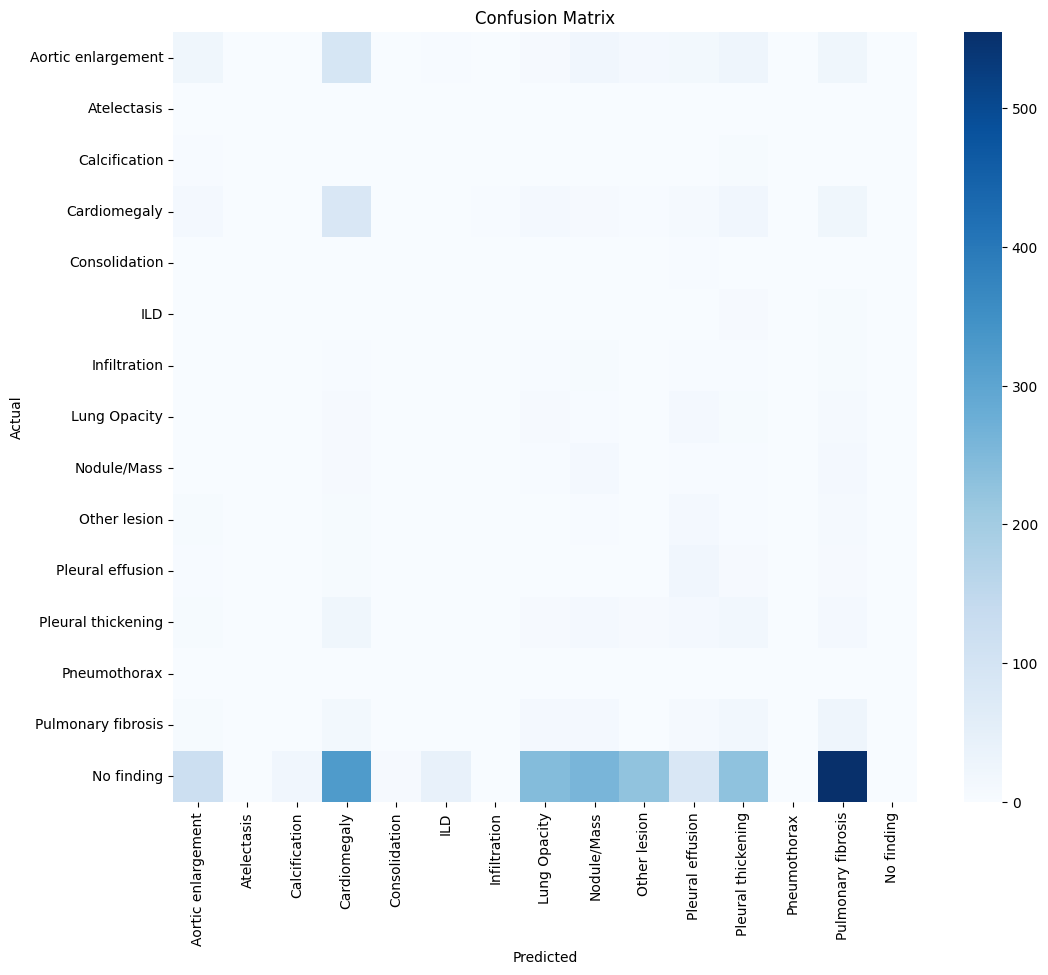

In [24]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=[class_dict[i] for i in range(15)],
    yticklabels=[class_dict[i] for i in range(15)]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

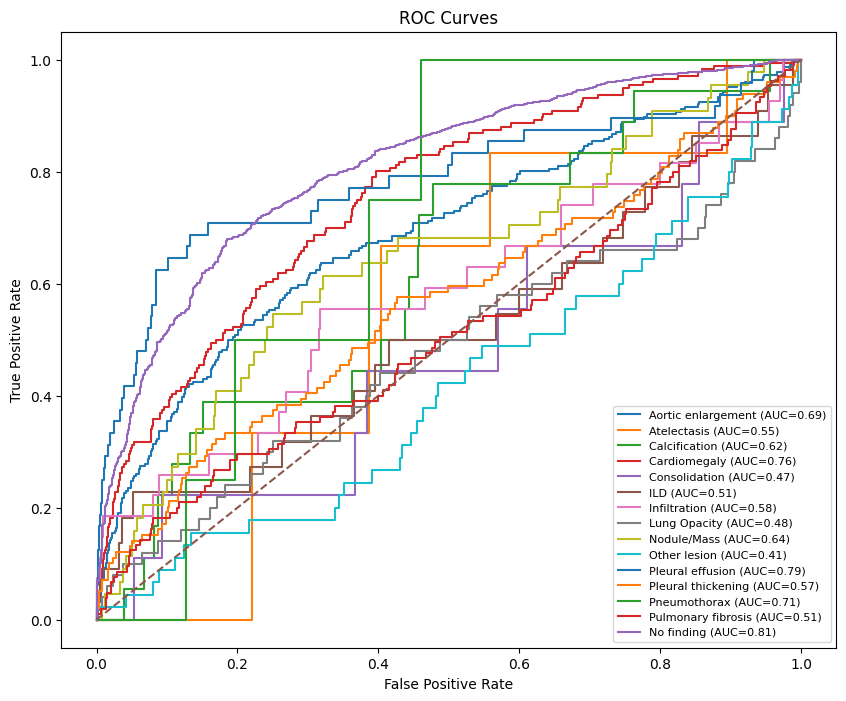

In [25]:
# Binarize labels
labels_bin = label_binarize(all_labels, classes=list(range(15)))

plt.figure(figsize=(10,8))

for i in range(15):

    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_dict[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend(fontsize=8)

plt.show()